<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 5: Regresión Logística para reviews de Peliculas</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad se abordará la implementación de un modelo de aanálisis de sentimientos para peliculas. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Considere el review de peliculas del archivo "moviereviews.tsv" que se encuentr en la carpeta Data</li>
<li>Cree un modelo de Regresión Logística para clasificación de sentimientos con las funciones vistas en clase.</li>

</ul>
</div>

In [1]:
import csv
import numpy as np
textos_bin =[]
res=[]
with open('Data/moviereviews.tsv', 'r', encoding='utf-8') as file:
    reader = csv.reader(file, delimiter='\t')
    next(reader) #Salta el encabezado
    idx =0
    for row in reader:
        if idx < 10:
            print(row)
        idx +=1
        textos_bin.append(row[1])
        if len(row) >= 2 and row[0] == 'pos':
            res.append(1)
        else:
            res.append(0)
    y_bin = np.array(res)

['neg', 'how do films like mouse hunt get into theatres ? \nisn\'t there a law or something ? \nthis diabolical load of claptrap from steven speilberg\'s dreamworks studio is hollywood family fare at its deadly worst . \nmouse hunt takes the bare threads of a plot and tries to prop it up with overacting and flat-out stupid slapstick that makes comedies like jingle all the way look decent by comparison . \nwriter adam rifkin and director gore verbinski are the names chiefly responsible for this swill . \nthe plot , for what its worth , concerns two brothers ( nathan lane and an appalling lee evens ) who inherit a poorly run string factory and a seemingly worthless house from their eccentric father . \ndeciding to check out the long-abandoned house , they soon learn that it\'s worth a fortune and set about selling it in auction to the highest bidder . \nbut battling them at every turn is a very smart mouse , happy with his run-down little abode and wanting it to stay that way . \nthe sto

In [2]:
print("="*10,"Total de reseñas ","="*10)
print(f"Positivas: {y_bin.sum()}  Negativas: {(1-y_bin).sum()}  Total: {len(y_bin)}")


========== Total de reseñas  ==========
Positivas: 1000  Negativas: 1000  Total: 2000


In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class RegresionLogisticaSentimiento:
    """Regresion logistica binaria con gradiente descendente batch."""

    def __init__(self, lr=0.1, epochs=500, lambda_=0.01, umbral=0.5):
        self.lr = lr; self.epochs = epochs
        self.lambda_ = lambda_; self.umbral = umbral
        self.w = None; self.b = 0.0; self.historial = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _perdida(self, y_hat, y):
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        ce = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return ce + (self.lambda_ / 2) * np.dot(self.w, self.w)

    def fit(self, X, y, verbose=True):
        N, D = X.shape
        self.w = np.zeros(D); self.b = 0.0; self.historial = []
        for epoch in range(self.epochs):
            y_hat = self._sigmoid(X.dot(self.w) + self.b)
            loss = self._perdida(y_hat, y)
            self.historial.append(loss)
            error = y_hat - y
            grad_w = X.T.dot(error) / N + self.lambda_ * self.w
            grad_b = np.mean(error)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            if verbose and (epoch % 100 == 0 or epoch == self.epochs - 1):
                acc = accuracy_score(y, self.predecir(X))
                print(f"  Epoch {epoch:4d} | Perdida: {loss:.4f} | Acc train: {acc:.4f}")
        return self

    def predecir_proba(self, X):
        return self._sigmoid(X.dot(self.w) + self.b)

    def predecir(self, X):
        return (self.predecir_proba(X) >= self.umbral).astype(int)

    def palabras_importantes(self, vocab, top_n=10):
        idx_pos = np.argsort(self.w)[::-1][:top_n]
        idx_neg = np.argsort(self.w)[:top_n]
        return [(vocab[i], self.w[i]) for i in idx_pos], [(vocab[i], self.w[i]) for i in idx_neg]
    
    def predecir_texto(self, texto, vectorizer):
        X = vectorizer.transform([texto]).toarray()
        proba = self.predecir_proba(X)[0]
        pred = 1 if proba >= self.umbral else 0
        
        return {
            'sentimiento': 'POSITIVO' if pred == 1 else 'NEGATIVO',
            'prediccion': pred,
            'probabilidad_positiva': proba,
            'confianza': abs(proba - 0.5) * 2 * 100
        }

print("Clase RegresionLogisticaSentimiento lista.")


Clase RegresionLogisticaSentimiento lista.


In [4]:
# Vectorizacion TF-IDF
tfidf_lr = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)
X_bin = tfidf_lr.fit_transform(textos_bin).toarray()
vocab_lr = tfidf_lr.get_feature_names_out()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bin, y_bin, test_size=0.25, random_state=42, stratify=y_bin)
print(f"Train: {len(X_tr)}  Test: {len(X_te)}")

print()
print("Entrenando Regresion Logistica desde cero...")
print("=" * 55)
rl = RegresionLogisticaSentimiento(lr=0.3, epochs=500, lambda_=0.01)
rl.fit(X_tr, y_tr, verbose=True)


Train: 1500  Test: 500

Entrenando Regresion Logistica desde cero...
  Epoch    0 | Perdida: 0.6931 | Acc train: 0.9800
  Epoch  100 | Perdida: 0.6878 | Acc train: 0.9847
  Epoch  200 | Perdida: 0.6850 | Acc train: 0.9847
  Epoch  300 | Perdida: 0.6834 | Acc train: 0.9847
  Epoch  400 | Perdida: 0.6826 | Acc train: 0.9847
  Epoch  499 | Perdida: 0.6821 | Acc train: 0.9847


REPORTE EN CONJUNTO DE PRUEBA
              precision    recall  f1-score   support

    negativo       0.87      0.88      0.87       250
    positivo       0.88      0.87      0.87       250

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500



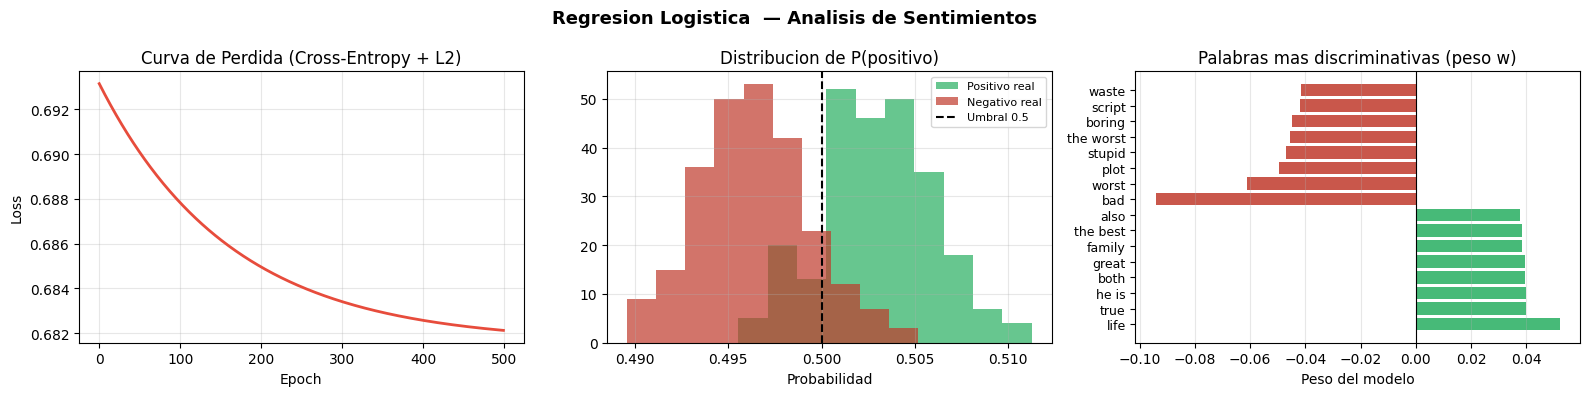

In [5]:
# --- Evaluacion ---
y_pred_bin  = rl.predecir(X_te)
y_proba_bin = rl.predecir_proba(X_te)

print("REPORTE EN CONJUNTO DE PRUEBA")
print("=" * 55)
print(classification_report(y_te, y_pred_bin, target_names=['negativo', 'positivo']))

# --- Visualizacion: 3 paneles ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Regresion Logistica  — Analisis de Sentimientos',
             fontsize=13, fontweight='bold')

# 1. Curva de perdida
axes[0].plot(rl.historial, color='#e74c3c', linewidth=2)
axes[0].set_title('Curva de Perdida (Cross-Entropy + L2)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

# 2. Distribucion de probabilidades
axes[1].hist(y_proba_bin[y_te == 1], bins=10, alpha=0.7, color='#27ae60', label='Positivo real')
axes[1].hist(y_proba_bin[y_te == 0], bins=10, alpha=0.7, color='#c0392b', label='Negativo real')
axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
axes[1].set_title('Distribucion de P(positivo)')
axes[1].set_xlabel('Probabilidad'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# 3. Palabras mas discriminativas
positivas, negativas = rl.palabras_importantes(vocab_lr, top_n=8)
all_words   = [w for w, _ in positivas] + [w for w, _ in negativas]
all_weights = [s for _, s in positivas] + [s for _, s in negativas]
colors_bar  = ['#27ae60'] * len(positivas) + ['#c0392b'] * len(negativas)
axes[2].barh(range(len(all_words)), all_weights, color=colors_bar, alpha=0.85)
axes[2].set_yticks(range(len(all_words)))
axes[2].set_yticklabels(all_words, fontsize=9)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Palabras mas discriminativas (peso w)')
axes[2].set_xlabel('Peso del modelo'); axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

In [12]:
nueva_resena ="The 1990 film Ghost is a great movie."
print("Prueba de predicción")
print(rl.predecir_texto(nueva_resena,tfidf_lr))

Prueba de predicción
{'sentimiento': 'POSITIVO', 'prediccion': 1, 'probabilidad_positiva': np.float64(0.5016135358034391), 'confianza': np.float64(0.32270716068782956)}


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
#Pipeline con LogisticRegression
pipeline_lr = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df = 1, max_features=5000, sublinear_tf = True)),
                        ('clr', LogisticRegression(C = 1.0, max_iter=1000, solver = 'lbfgs'))
    
]) 

X_train, X_test, y_train, y_test = train_test_split(
    textos_bin, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

In [15]:
pipeline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [16]:
y_hat_test = pipeline_lr.predict(X_test) #predicción de las reseñas de testeo

In [17]:
pipeline_lr.named_steps['clr'].coef_[0]

array([-0.0622484 , -0.0819987 , -0.03583186, ...,  0.19316256,
       -0.02426287, -0.13898526], shape=(5000,))

In [18]:
coeficientes_lr = pipeline_lr.named_steps['clr'].coef_[0]
print(f"Indicacores de negatividad: {np.argsort(coeficientes_lr)[:10]}")
print(f"Indicacores de positividad: {np.argsort(coeficientes_lr)[-10:]}")

Indicacores de negatividad: [ 423 4941 3172 3505 4584 2856  569 4238 3869 3608]
Indicacores de positividad: [3539 3108 1847  141 4538 4019 2425  572 1686 4766]


In [19]:
features_names_lr = pipeline_lr.named_steps['tfidf'].get_feature_names_out()
features_names_lr

array(['000', '10', '100', ..., 'your', 'yourself', 'zero'],
      shape=(5000,), dtype=object)

In [20]:
print(f"Palabras más negativas: {features_names_lr[np.argsort(coeficientes_lr)[:10]]}")
print(f"Palabras más positivas: {features_names_lr[np.argsort(coeficientes_lr)[-10:]]}")

Palabras más negativas: ['bad' 'worst' 'plot' 'script' 'unfortunately' 'nothing' 'boring'
 'the worst' 'supposed' 'should have']
Palabras más positivas: ['seen' 'perfectly' 'hilarious' 'also' 'true' 'the best' 'life' 'both'
 'great' 'well']


In [21]:
print(classification_report(y_test, y_hat_test, target_names = ['Neg', 'Pos']))

              precision    recall  f1-score   support

         Neg       0.87      0.88      0.87       300
         Pos       0.88      0.87      0.87       300

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



In [24]:
nueva_resena ="The 1990 film Ghost is a great movie."

prediccion = pipeline_lr.predict([nueva_resena])
probabilidad = pipeline_lr.predict_proba([nueva_resena])
sentimiento = "POSITIVO" if prediccion[0] == 1 else "NEGATIVO"
prob_positiva = probabilidad[0][1]  

print(f"Reseña: {nueva_resena}")
print(f"Sentimiento: {sentimiento}")
print(f"Probabilidad positiva: {prob_positiva:.2%}")

Reseña: The 1990 film Ghost is a great movie.
Sentimiento: POSITIVO
Probabilidad positiva: 56.00%
